# EDA: Synthetic CIB Data — Cohort Sanity Check

**Purpose:** before building any features or models on top of the synthetic
generator (`src/data_generation/generate_synthetic_data.py`), visually confirm
that the four simulated cohorts actually look like what they're supposed to:

| Cohort | Expected shape |
|---|---|
| `stable` | flat, noisy, no trend |
| `gradual_deterioration` | slow multi-month decline to a lower plateau |
| `sudden_deterioration` | sharp 1-2 month drop, then plateau |
| `seasonal_false_positive` | periodic dips that **recover** — must NOT look like real deterioration |

`ground_truth_cohort` is only used here for validation — it is never a model
feature.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import CUSTOMERS_FILE, MONTHLY_PANEL_FILE, GROUND_TRUTH_FILE, COUNTERPARTY_TXNS_FILE

sns.set_theme(style="whitegrid", palette="deep")

customers = pd.read_parquet(CUSTOMERS_FILE)
panel = pd.read_parquet(MONTHLY_PANEL_FILE)
ground_truth = pd.read_parquet(GROUND_TRUTH_FILE)
counterparties = pd.read_parquet(COUNTERPARTY_TXNS_FILE)

panel = panel.merge(ground_truth[["customer_id", "ground_truth_cohort"]], on="customer_id")
panel["month_idx"] = panel.groupby("customer_id").cumcount()

print(panel.shape, ground_truth["ground_truth_cohort"].value_counts(normalize=True).round(3).to_dict())
panel.head()

(90000, 16) {'stable': 0.539, 'gradual_deterioration': 0.206, 'seasonal_false_positive': 0.152, 'sudden_deterioration': 0.102}


,customer_id,month,average_monthly_balance,transaction_count_debit,transaction_count_credit,transaction_value_debit,transaction_value_credit,digital_login_count,mobile_banking_txn_pct,payroll_credit_flag,payroll_credit_amount,trade_finance_utilization_pct,complaint_count,service_ticket_count,ground_truth_cohort,month_idx
0,CIB100000,2024-03,4.464,43,40,25.991,25.619,28.0,59.34,0,0.0,NaN,0,0.0,gradual_deterioration,0
1,CIB100000,2024-04,4.232,44,48,31.070,30.625,29.0,NaN,0,0.0,NaN,0,0.0,gradual_deterioration,1
2,CIB100000,2024-05,4.209,60,45,32.915,32.444,31.0,53.11,0,0.0,NaN,0,0.0,gradual_deterioration,2
3,CIB100000,2024-06,4.394,41,37,22.647,22.323,29.0,63.33,0,0.0,NaN,0,0.0,gradual_deterioration,3
4,CIB100000,2024-07,4.200,31,55,32.268,31.805,31.0,59.49,0,0.0,NaN,1,0.0,gradual_deterioration,4


## Normalize AMB per customer

Customers span ~0.3 Cr (SME) to ~150 Cr (Large Corporate) in baseline balance,
so raw AMB can't be averaged across a cohort directly. Instead we express each
customer's AMB as a **fraction of their own first-3-month baseline** — this
puts everyone on the same scale (1.0 = healthy baseline) so cohort shapes
become comparable regardless of company size.

In [2]:
baseline = (
    panel[panel["month_idx"] < 3]
    .groupby("customer_id")["average_monthly_balance"]
    .mean()
    .rename("baseline_amb")
)
panel = panel.merge(baseline, on="customer_id")
panel["amb_relative"] = panel["average_monthly_balance"] / panel["baseline_amb"]

## 1. Mean AMB trajectory by cohort (with IQR band)

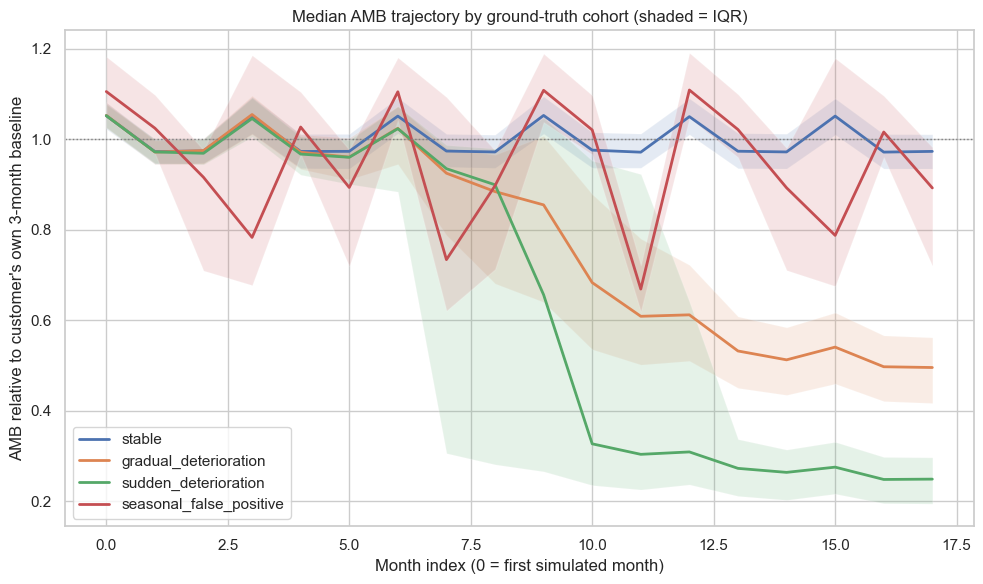

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
cohort_order = ["stable", "gradual_deterioration", "sudden_deterioration", "seasonal_false_positive"]

for cohort in cohort_order:
    sub = panel[panel["ground_truth_cohort"] == cohort]
    grouped = sub.groupby("month_idx")["amb_relative"]
    median = grouped.median()
    q25, q75 = grouped.quantile(0.25), grouped.quantile(0.75)
    ax.plot(median.index, median.values, label=cohort, linewidth=2)
    ax.fill_between(median.index, q25.values, q75.values, alpha=0.15)

ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
ax.set_xlabel("Month index (0 = first simulated month)")
ax.set_ylabel("AMB relative to customer's own 3-month baseline")
ax.set_title("Median AMB trajectory by ground-truth cohort (shaded = IQR)")
ax.legend()
fig.tight_layout()
fig.savefig("../docs/figures/amb_trajectory_by_cohort.png", dpi=150)
plt.show()

## 2. Individual customer trajectories (small multiples) — does it look like *messy real data*, not a clean synthetic curve?

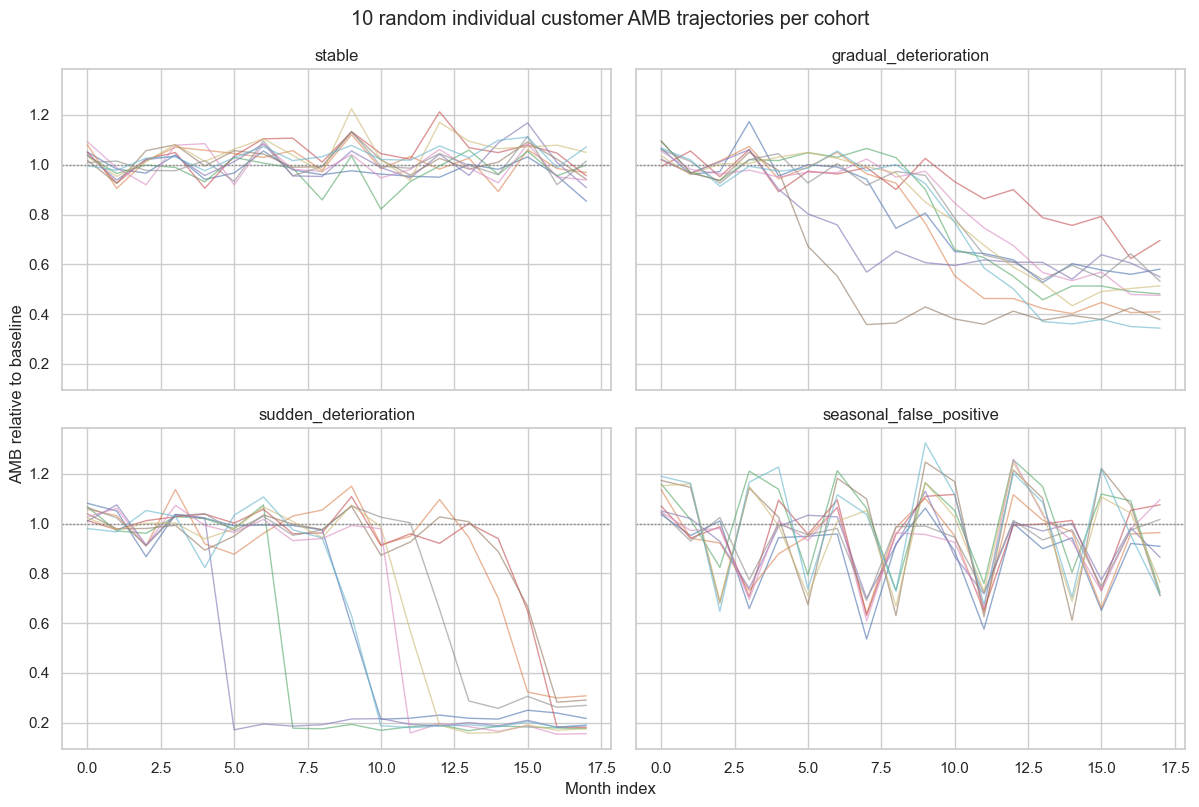

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
rng = np.random.default_rng(7)

for ax, cohort in zip(axes.flat, cohort_order):
    sub = panel[panel["ground_truth_cohort"] == cohort]
    sample_ids = rng.choice(sub["customer_id"].unique(), size=10, replace=False)
    for cid in sample_ids:
        cust_series = sub[sub["customer_id"] == cid].sort_values("month_idx")
        ax.plot(cust_series["month_idx"], cust_series["amb_relative"], alpha=0.6, linewidth=1)
    ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
    ax.set_title(cohort)

fig.suptitle("10 random individual customer AMB trajectories per cohort")
fig.text(0.5, 0.0, "Month index", ha="center")
fig.text(0.0, 0.5, "AMB relative to baseline", va="center", rotation="vertical")
fig.tight_layout()
fig.savefig("../docs/figures/amb_individual_trajectories.png", dpi=150)
plt.show()

## 3. Wallet leakage check: competitor-bank counterparty share over time by cohort

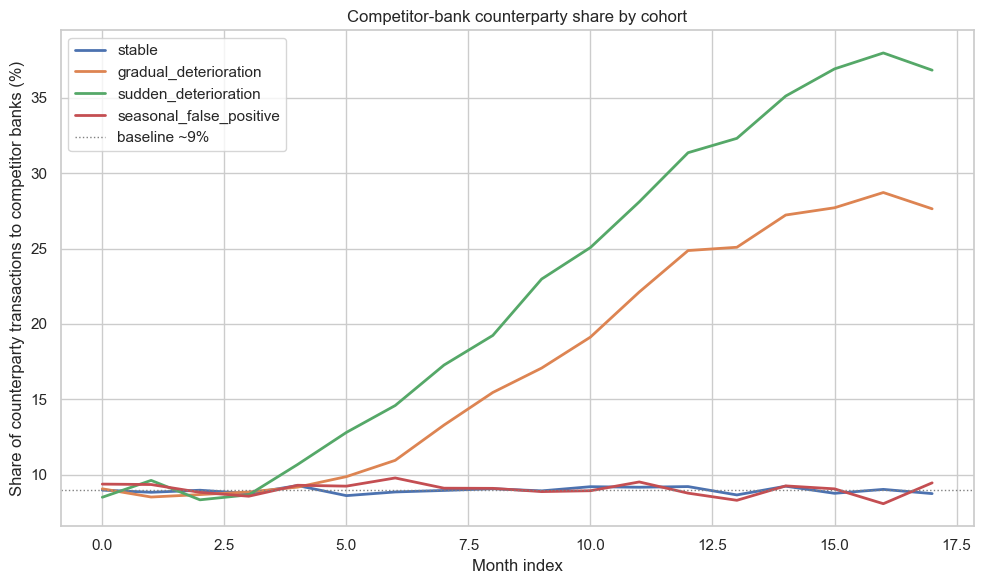

In [5]:
cp = counterparties.merge(ground_truth[["customer_id", "ground_truth_cohort"]], on="customer_id")
cp["month_idx"] = cp.groupby("customer_id")["month"].rank(method="dense").astype(int) - 1

fig, ax = plt.subplots(figsize=(10, 6))
for cohort in cohort_order:
    sub = cp[cp["ground_truth_cohort"] == cohort]
    share = sub.groupby("month_idx")["is_competitor_bank"].mean()
    ax.plot(share.index, share.values * 100, label=cohort, linewidth=2)

ax.axhline(9, color="grey", linestyle=":", linewidth=1, label="baseline ~9%")
ax.set_xlabel("Month index")
ax.set_ylabel("Share of counterparty transactions to competitor banks (%)")
ax.set_title("Competitor-bank counterparty share by cohort")
ax.legend()
fig.tight_layout()
fig.savefig("../docs/figures/competitor_share_by_cohort.png", dpi=150)
plt.show()

## Takeaways

- `stable` sits flat around 1.0 with only noise, as expected.
- `gradual_deterioration` shows a slow multi-month bleed to a lower plateau,
  and its competitor-bank share climbs in step — the "wallet share shifting
  away" story the project is built around.
- `sudden_deterioration` drops sharply within 1-2 months (the simulated
  payroll-migration event) and then plateaus at a lower level.
- `seasonal_false_positive` dips periodically but **recovers** every cycle,
  and critically its competitor-bank share stays flat — confirming this
  cohort is a genuine trap for label construction (Phase 2 must not flag it).

This confirms the synthetic data is ready to build features and labels on
top of.